# 03 3DEP Offset Diagnosis

Purpose:
- read outputs from `diagnose_3dep_offsets.py`,
- inspect empirical offsets, formal transformation residuals, and pair consistency,
- keep the notebook lightweight instead of re-running heavy matching.

Scientific notes:
- CASALS refh is treated here as WGS84 ellipsoidal height.
- 3DEP products may use NAVD88 and project-specific frames.
- Pair-to-pair interpretation must keep product semantics and vertical datum issues explicit.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next((candidate for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (candidate / "casals_l1b" / "waveform.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the CASALS project root.")
OUT_DIR = PROJECT_ROOT / "outputs" / "baseline_pre_refactor" / "root_existing" / "diagnose_3dep_offsets"
SUMMARY_CSV = OUT_DIR / 'per_pair_summary.csv'
SUMMARY_JSON = OUT_DIR / 'per_pair_summary.json'
summary = pd.read_csv(SUMMARY_CSV)
payload = json.loads(SUMMARY_JSON.read_text(encoding='utf-8'))
summary

,label,h5_path,dep_las_path,error
0,casals_20241112_MD_Southeast_1_2019,casals_h5_downloads\casals_l1b_20241112T165718...,point_cloud_data\download_3dep_lpc\casals_l1b_...,[Errno 2] Unable to synchronously open file (u...
1,casals_20241112_DE_Statewide_1_B23,casals_h5_downloads\casals_l1b_20241112T170442...,point_cloud_data\download_3dep_lpc\casals_l1b_...,[Errno 2] Unable to synchronously open file (u...
2,casals_20241118_NC_HurricaneFlorence_9_2020,casals_h5_downloads\casals_l1b_20241118T171757...,point_cloud_data\download_3dep_lpc\casals_l1b_...,[Errno 2] Unable to synchronously open file (u...


In [2]:
cols = [c for c in summary.columns if 'offset' in c or 'residual' in c]
print('offset-related columns:', cols)
summary[['label'] + cols[:8]] if cols else summary[['label']]

offset-related columns: []


,label
0,casals_20241112_MD_Southeast_1_2019
1,casals_20241112_DE_Statewide_1_B23
2,casals_20241118_NC_HurricaneFlorence_9_2020


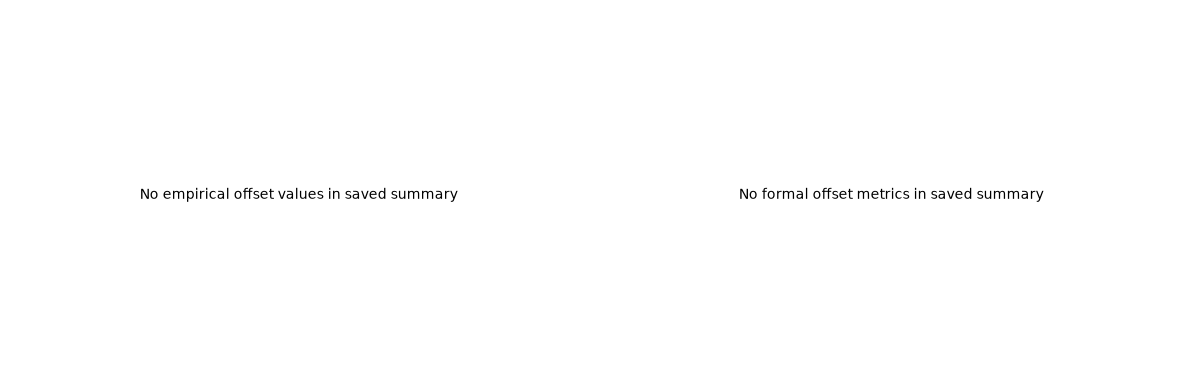

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if "empirical_offset_m" in summary.columns and pd.to_numeric(summary["empirical_offset_m"], errors="coerce").notna().any():
    summary.plot.bar(x="label", y="empirical_offset_m", ax=axes[0], color="tab:blue", legend=False)
    axes[0].set_title("Empirical offset by pair")
    axes[0].set_ylabel("meters")
else:
    axes[0].text(0.5, 0.5, "No empirical offset values in saved summary", ha="center", va="center")
    axes[0].set_axis_off()

formal_cols = [c for c in summary.columns if c.startswith("formal_") and c.endswith("_median_m")]
if formal_cols:
    summary.plot(x="label", y=formal_cols, marker="o", ax=axes[1])
    axes[1].set_title("Formal transformation medians")
    axes[1].set_ylabel("meters")
else:
    axes[1].text(0.5, 0.5, "No formal offset metrics in saved summary", ha="center", va="center")
    axes[1].set_axis_off()

fig.tight_layout()

In [4]:
for label, report in payload.get('pair_reports', {}).items():
    print('\nPAIR:', label)
    print('scientific_notes:', report.get('scientific_notes', []))
    print('matching:', report.get('matching', {}))
    print('empirical_offset:', report.get('empirical_offset', {}))